# VLM training (v1)

Thin orchestration notebook: imports model + training code from `GPT.py`, `ViT.py`, `VLM.py`. Skips ViT pretraining (loads existing checkpoint). Reuses VLM definition, checkpoint loading, and training loop from `VLM.py`.

In [1]:
import os
import sys
sys.path.insert(0, '..')
sys.path.insert(0, '../src')
sys.path.insert(0, '../src/model')

import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from PIL import Image
from transformers import AutoTokenizer

from src.model.GPT import GPT
from src.model.ViT import ViT
from src.model.VLM import VLM, CustomViTAdapter, SigLIPAdapter
from src.configs import (
    ConfigParametersLLM,
    ConfigParametersViT,
    ConfigParametersVLM,
    OptimParametersVLM,
)
from src.vision_datasets import val_tfm, train_tfm, build_vlm_dataloaders, build_coco_dataloaders
from src.train_helper import validate_vlm
from src.utils import vlm_from_config, llm_from_config, vision_encoder_from_config

from transformers import SiglipVisionModel

/home/pensativo/code/vision-ai-guide/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Setup: tokenizer, device, paths

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

tokenizer = AutoTokenizer.from_pretrained("gpt2")
tokenizer.pad_token = tokenizer.eos_token


VLM_OUTPUT_DIR = "../outputs/vlm_siglip"
DATA_DIR = "../data/coco"

if  not os.path.exists(VLM_OUTPUT_DIR):
    os.makedirs(VLM_OUTPUT_DIR, exist_ok=True)

## Build configs

In [3]:
"""for custom vit use: 
"vision_encoder": {
          "type": "custom_vit",
          "config_path": "../configs/custom_vit_config_params.json",
    }
"""

vlm_config = {
    "device": device,

    
    "vision_encoder": {
      "type": "siglip",
      "model_name": "google/siglip-base-patch16-224"
      },


    "llm": {
          "type": "custom_gpt",
          "config_path": "../configs/custom_gpt_config_params.json",
          "checkpoint_path": "../outputs/llm_rope/llm_wikitext_rope_final.pt"
    },

    "vlm": {
          "batch_size": 32,
          "output_dim": 768 #vision encoder linear projection dim
    },

    "optim": {
            "lr": 1e-4, #learning rate
            "min_lr": 1e-5, #minimum learning rate
            "betas": (0.9, 0.95), #betas
            "eps": 1e-8, #epsilon
            "scheduler": True, #use a learning rate scheduler
            "compile": True, #compile the model
            "autocast": True, #autocast
            "autocast_dtype": torch.bfloat16, #autocast dtype
            "min_lr": 1e-5, #minimum learning rate
            "warmup_steps": 500, #warmup steps
            "max_steps": 40000 #max steps
    }
  }

## Build VLM and optimizer

In [ ]:
vlm_model = vlm_from_config(vlm_config).to(device)
opt_cfg = OptimParametersVLM(**vlm_config["optim"])

optimizer = torch.optim.AdamW(
    [p for p in vlm_model.parameters() if p.requires_grad],
    lr=opt_cfg.lr, betas=opt_cfg.betas, eps=opt_cfg.eps,
)

scheduler = None
if opt_cfg.scheduler is not None:
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=opt_cfg.max_steps)

if opt_cfg.compile is not None:
    vlm_model = torch.compile(vlm_model).to(device)

Loading weights: 100%|██████████| 208/208 [00:00<00:00, 1517.29it/s, Materializing param=vision_model.post_layernorm.weight]                      
SiglipVisionModel LOAD REPORT from: google/siglip-base-patch16-224
Key                                                          | Status     |  | 
-------------------------------------------------------------+------------+--+-
text_model.encoder.layers.{0...11}.self_attn.k_proj.weight   | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.mlp.fc1.weight            | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.q_proj.weight   | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.v_proj.bias     | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.mlp.fc1.bias              | UNEXPECTED |  | 
text_model.embeddings.token_embedding.weight                 | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.mlp.fc2.weight            | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.layer_norm1.bias          | UNE

## Build dataloaders

In [5]:
train_loader, val_loader = build_coco_dataloaders(                                                                                                                                    
      tokenizer,
      batch_size=vlm_config["vlm"]["batch_size"],                                                                                                                                                                   
      num_workers=4, 
      data_dir=DATA_DIR,                                       
      # val_limit=500 by default — 500 pairs for quick eval
      # train_limit=None      — use all 591K train pairs                                                                                                                                
  )
print(f"train batches: {len(train_loader):,}")   # ~18,500 at batch=32                                                                                                                
print(f"val batches:   {len(val_loader):,}")     # ~16 at batch=32, val_limit=500 
print(f"train batches: {len(train_loader)}")
print(f"val batches:   {len(val_loader)}")

train batches: 18,493
val batches:   16
train batches: 18493
val batches:   16


## Train VLM

In [6]:
def save_checkpoint(
    ckpt_path: str, 
    step: int, 
    model: torch.nn.Module, 
    optimizer: torch.optim.Optimizer, 
    scheduler: torch.optim.lr_scheduler.LRScheduler, 
    train_loss: list,
    opt_cfg: OptimParametersVLM)->None:

    """Save the model, optimizer, and scheduler state dictionaries to a checkpoint file.
    Args:
        ckpt_path: str, path to save the checkpoint file
        step: int, current step number
        model: torch.nn.Module, model to save
        optimizer: torch.optim.Optimizer, optimizer to save
        scheduler: torch.optim.lr_scheduler.LRScheduler, scheduler to save
        train_loss: list, training loss values
    """
    if opt_cfg.compile is not None:
        raw_model = getattr(model, "_orig_mod", model) 

    payload = {    
        "step": step,
        "model": raw_model.state_dict(),
        "train_loss": train_loss,
        "optimizer": optimizer.state_dict(),
        "scheduler": scheduler.state_dict() if scheduler is not None else None
    }
    tmp = ckpt_path + ".tmp"
    torch.save(payload, tmp)                                                                                                                                                          
    os.replace(tmp, ckpt_path)

In [7]:
def train_vlm(model, train_loader, val_loader=None, optimizer=None, device=None, max_steps=None, validation=True):
    model.train()
    step = 0
    train_loss: list[float] = []
    val_loss: list[float] = []
    print_every = max_steps // 20
    save_every = max_steps // 10

    while step < max_steps:
        for img, text_tokens, attention_mask, targets in train_loader:
            img = img.to(device)
            text_tokens = text_tokens.to(device)
            attention_mask = attention_mask.to(device)
            targets = targets.to(device)
            
            
            optimizer.zero_grad()

            #autocast to bf16 for faster training
            if opt_cfg.autocast is not None:
                with torch.autocast(device_type="cuda", dtype=opt_cfg.autocast_dtype):     
                    logits, loss = model(
                                    x_img=img, x_text=text_tokens,
                                    targets=targets, attention_mask=attention_mask,
                                    )
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()  
            if opt_cfg.scheduler:                                                                                                                                                          
                scheduler.step() 

            train_loss.append(loss.item())
            step += 1

            if step % print_every == 0:
                print(f"Step {step} | Loss {loss.item():.4f}")
        
            if step % save_every == 0:
                ckpt_path = os.path.join(VLM_OUTPUT_DIR, f"vlm_coco_captions{step:07d}.pt")
                save_checkpoint(
                    ckpt_path=os.path.join(VLM_OUTPUT_DIR, f"vlm_coco_captions{step:07d}.pt"),
                    step=step,
                    model=model,
                    optimizer=optimizer,
                    scheduler=scheduler,
                    train_loss=train_loss,
                    opt_cfg=opt_cfg
                )

                print(f"Checkpoint saved at step {step}")


                #validation
                
                if val_loader is not None and validation:
                    autocast_dtype = opt_cfg.autocast_dtype
                    vlm_model.eval()
                    with torch.inference_mode():
                        v_loss = validate_vlm(                                                                                                                                                          
                                vlm_model, val_loader, device,
                                max_batches=20,                       # ~640 caption pairs at batch=32                                                                                                        
                                autocast_dtype=autocast_dtype
                            )                                                                                                                                            
                        print(f"Validation loss: {v_loss:.4f}")
                        val_loss.append(v_loss)
                    vlm_model.train()
            

            if step >= max_steps:
                break

    ckpt_path = os.path.join(VLM_OUTPUT_DIR, "vlm_coco_captions_rope_final.pt")
    torch.save(
        {"step": step, "model": model.state_dict(), "train_loss": train_loss},
        ckpt_path,
    )
    print(f"Saved checkpoint to {ckpt_path}")
    return train_loss, val_loss

## VLM training with custom ViT and custom GPT

In [16]:
###with rope embeddings
train_loss_r, val_loss_r = train_vlm(vlm_model, train_loader, val_loader, optimizer, device, max_steps=opt_cfg.max_steps, validation=True)

Step 2000 | Loss 2.5671
Step 4000 | Loss 2.8636
Checkpoint saved at step 4000
Validation loss: 2.8922
Step 6000 | Loss 2.7945
Step 8000 | Loss 2.4798
Checkpoint saved at step 8000
Validation loss: 2.8566
Step 10000 | Loss 2.6643
Step 12000 | Loss 2.0024
Checkpoint saved at step 12000
Validation loss: 2.8227
Step 14000 | Loss 2.4654
Step 16000 | Loss 2.5554
Checkpoint saved at step 16000
Validation loss: 2.7750
Step 18000 | Loss 2.2770
Step 20000 | Loss 2.5466
Checkpoint saved at step 20000
Validation loss: 2.7374
Step 22000 | Loss 2.3029
Step 24000 | Loss 2.6324
Checkpoint saved at step 24000
Validation loss: 2.7184
Step 26000 | Loss 2.6406
Step 28000 | Loss 2.4748
Checkpoint saved at step 28000
Validation loss: 2.7014
Step 30000 | Loss 2.2535
Step 32000 | Loss 2.3898
Checkpoint saved at step 32000
Validation loss: 2.7121
Step 34000 | Loss 2.3635
Step 36000 | Loss 2.1513
Checkpoint saved at step 36000
Validation loss: 2.6829
Step 38000 | Loss 2.1238
Step 40000 | Loss 2.1649
Checkpoint 

## plot train and val loss

In [38]:
def draw_plot(loss_list):
    window = 100
    if len(loss_list) >= window:
        smoothed = [
            sum(loss_list[i:i+window]) / window
            for i in range(len(loss_list) - window + 1)
        ]
        plt.plot(loss_list, alpha=0.2, label="raw")
        plt.plot(range(window - 1, len(loss_list)), smoothed, label="smoothed")
    else:
        plt.plot(loss_list, label="raw")

    plt.xlabel("Step")
    plt.ylabel("Loss")
    plt.title("VLM Train Loss")
    plt.legend()
    plt.show()

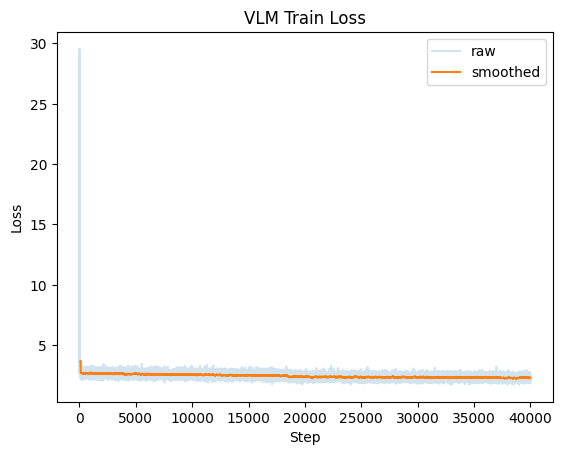

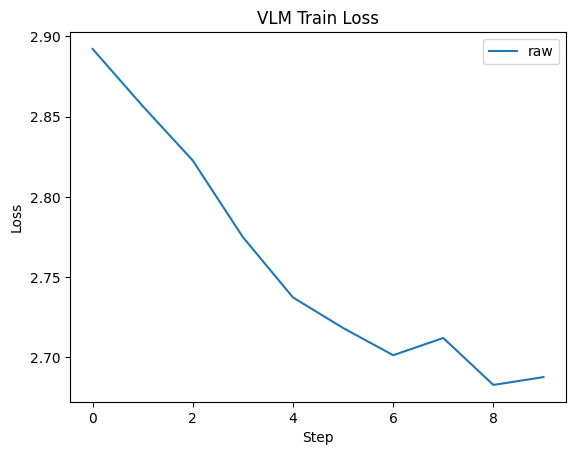

In [40]:
draw_plot(train_loss_r)
draw_plot(val_loss_r)

## Inference 

In [ ]:
def prepare_inference_input(
    messages: list[dict],
    tokenizer,
    max_len: int,
    transform,
    root: str | None = None,
) -> dict:
    """Convert a chat-style message into VLM model inputs (single sample)."""
    content = messages[0]["content"]
    img = None
    text = None

    for item in content:
        if item["type"] == "image":
            image_path = item.get("path") or item.get("url")
            if root is not None and not os.path.isabs(image_path):
                image_path = os.path.join(root, image_path)
            img = Image.open(image_path).convert("RGB")
            img = transform(img)
        elif item["type"] == "text":
            text = item["text"]

    text_ids = tokenizer(text, add_special_tokens=False)["input_ids"][:max_len]
    text_tokens = torch.tensor(text_ids, dtype=torch.long).unsqueeze(0)

    if tokenizer.pad_token_id is None:
        tokenizer.pad_token = tokenizer.eos_token

    attention_mask = torch.ones_like(text_tokens)

    return {
        "image": img.unsqueeze(0),
        "text_tokens": text_tokens,
        "attention_mask": attention_mask,
    }

In [20]:
#load VLM model
ckpt = torch.load("../outputs/vlm_rope/vlm_coco_captions_rope_final.pt")
state_dict = {k.removeprefix("_orig_mod."): v for k, v in ckpt["model"].items()}
                                              
vlm_model = build_vlm(vit_model, llm_model, vlm_config, device)                                                                                                                       
vlm_model.load_state_dict(state_dict)                                                                                                                                                 
vlm_model.to(device)                                                                                                                                                                  
vlm_model.eval()  

VLM(
  (vision_encoder): ViT(
    (blocks): ModuleList(
      (0-3): 4 x TransformerBlock(
        (MHSA): MultiHeadAttention(
          (q_proj): Linear()
          (k_proj): Linear()
          (v_proj): Linear()
          (o_proj): Linear()
          (pos_emb): RotaryPositionalEmbeddings()
        )
        (layernorm1): LayerNormalization()
        (layernorm2): LayerNormalization()
        (FFN): Sequential(
          (0): Linear()
          (1): GLU()
          (2): Linear()
        )
      )
    )
    (logit_proj): Linear()
    (x_proj): Linear()
  )
  (LLM): GPT(
    (blocks): ModuleList(
      (0-3): 4 x TransformerBlock(
        (MHSA): MultiHeadAttention(
          (q_proj): Linear()
          (k_proj): Linear()
          (v_proj): Linear()
          (o_proj): Linear()
          (pos_emb): RotaryPositionalEmbeddings()
        )
        (layernorm1): LayerNormalization()
        (layernorm2): LayerNormalization()
        (FFN): Sequential(
          (0): Linear()
          (1)

text_tokens: [7571, 661, 5586, 319, 257, 18757, 287, 262, 4675, 1306, 284, 257, 10481, 13, 50256]
caption (decoded): 'Two people sitting on a motorcycle in the street next to a beach.'

image path: ../data/coco/val2017/000000102411.jpg
caption used at idx 350: 'Two people sitting on a motorcycle in the street next to a beach.'


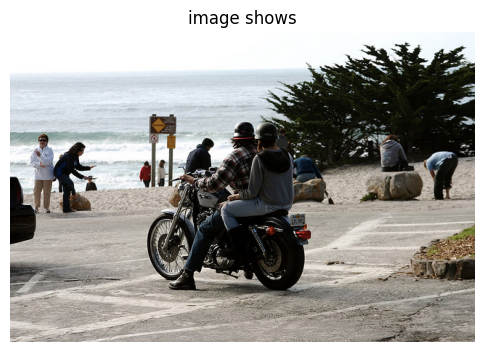

 a man riding a motorcycle down a street.


In [37]:
idx = 350                                                                                                 
                                                                                                                                                                                        
# Inspect what the dataloader sees       
val_ds  = val_loader.dataset                                                                                                                                             
sample = val_ds[idx]                                                                                                                                                                  
print(f"text_tokens: {sample['text_tokens'].tolist()}")                                                                                                                               
print(f"caption (decoded): {tokenizer.decode(sample['text_tokens'], skip_special_tokens=True)!r}")                                                                                    
                                                                                                                                                                                        
# Image path + all reference captions for this image                                                                                                                                  
file_name, caption_used = val_ds.samples[idx]                                                                                                                                         
image_path = os.path.join(val_ds.image_dir, file_name)                                                                                                                                
print(f"\nimage path: {image_path}")                                                                                                                                                  
print(f"caption used at idx {idx}: {caption_used!r}") 

messages = [
    {
        "role": "user",
        "content": [
            {
                "type": "image",
                "path": image_path,
            },
            {
                "type": "text",
                "text": "image shows"
            },
        ],
    }
]

vlm_model.eval()
inputs = prepare_inference_input(messages, tokenizer, max_len=512, transform=val_tfm)
image = inputs["image"].to(device)
text_tokens = inputs["text_tokens"].to(device)
attention_mask = inputs["attention_mask"].to(device)

with torch.inference_mode():
    generated_ids = vlm_model.generate(
        image,
        text_tokens,
        attention_mask,
        max_new_tokens=100,
        eos_token_id=tokenizer.eos_token_id,
    )

image_path = messages[0]["content"][0]["path"]
prompt_text = messages[0]["content"][1]["text"]

pil_img = Image.open(image_path).convert("RGB")
plt.figure(figsize=(6, 6))
plt.imshow(pil_img)
plt.axis("off")
plt.title(prompt_text)
plt.show()

print(tokenizer.batch_decode(generated_ids, skip_special_tokens=True)[0])

In [8]:
### Training with SigLIP vision encoder
train_loss_s, val_loss_s = train_vlm(vlm_model, train_loader, val_loader, optimizer, device, max_steps=opt_cfg.max_steps, validation=True)

TorchRuntimeError: RuntimeError when making fake tensor call
  Explanation: Dynamo failed to run FX node with fake tensors: call_function <built-in method matmul of type object at 0xebb7756ccb80>(*(FakeTensor(..., device='cuda:0', size=(32, 196, 768),
               grad_fn=<NativeLayerNormBackward0>), Parameter(FakeTensor(..., size=(768, 768), requires_grad=True))), **{}): got RuntimeError('Unhandled FakeTensor Device Propagation for aten.mm.default, found two different devices cuda:0, cpu')
  Hint: Your code may result in an error when running in eager. Please double check that your code doesn't contain a similar error when actually running eager/uncompiled. You can do this by removing the `torch.compile` call, or by using `torch.compiler.set_stance("force_eager")`. 

  Developer debug context: 

 For more details about this graph break, please visit: https://meta-pytorch.github.io/compile-graph-break-site/gb/gb4315.html

from user code:
   File "/home/pensativo/code/vanilla-vit-gpt/